In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import (
    ROUND_NAMES,
    add_recent_form,
    get_current_form,
    load_results,
    print_champion,
    print_round,
    team_label,
)

In [2]:
# Partie 1 - Les données : 30 ans de football international
df = load_results("data/results.csv")

print(f"{len(df)} matchs chargés, de {df['year'].min()} à {df['year'].max()}")
display(df.head())

assert len(df) > 45000, "Le fichier semble incomplet, retélécharge-le depuis GitHub"
assert list(df.columns[:6]) == ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament'], \
    "Les colonnes ne correspondent pas, vérifie que tu as bien téléchargé results.csv"
print("Données chargées, on peut y aller !")

49505 matchs chargés, de 1872 à 2026


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876


Données chargées, on peut y aller !


In [3]:
# Filtrage du Dataset pour se limiter à l'ère moderne (les matchs joués entre le 1er janvier 1994 et le 30 juin 2026)
df = df[(df["date"] > "1994-01-01") & (df["date"] < "2026-06-30")]

print(f"{len(df)} matchs conservés, de {df['year'].min()} à {df['year'].max()}")

assert df["year"].min() == 1994, f"Le premier match doit dater de 1994, pas de {df['year'].min()}"
assert str(df["date"].max()) <= "2026-06-30 00:00:00", "Il reste des matchs après le 30 juin 2026"
assert 28000 < len(df) < 32000, f"Tu devrais avoir environ 30 000 matchs, tu en as {len(df)}"
print("Exercice validé !")

29978 matchs conservés, de 1994 à 2026
Exercice validé !


In [4]:
df = df.copy()
df["outcome"] = "draw"
df.loc[df["home_score"] > df["away_score"], "outcome"] = "home_win"
df.loc[df["home_score"] < df["away_score"], "outcome"] = "away_win"

display(df["outcome"].value_counts())

outcome
home_win    14543
away_win     8444
draw         6991
Name: count, dtype: int64

outcome
home_win    0.509046
away_win    0.258556
draw        0.232398
Name: proportion, dtype: float64

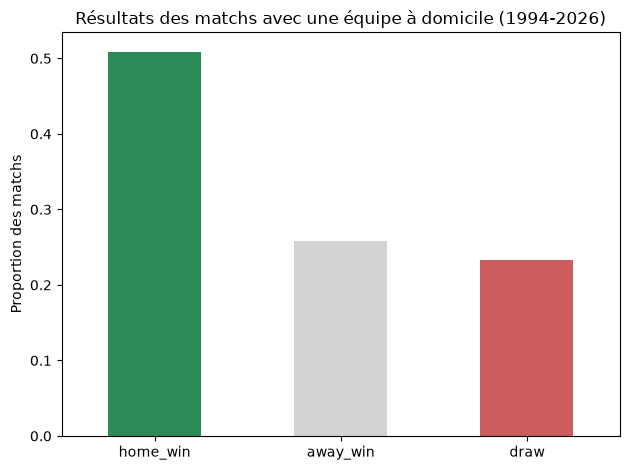

Exercice validé ! Yannis n'a pas tort : à domicile, on gagne 1 match sur 2.


In [5]:
# Débat 1 : l'avantage du terrain, mythe ou réalité ?
home_advantage = df[(df["neutral"] == False)]["outcome"].value_counts(normalize=True)

display(home_advantage)

home_advantage.plot(kind="bar", color=["seagreen", "lightgray", "indianred"])
plt.title("Résultats des matchs avec une équipe à domicile (1994-2026)")
plt.ylabel("Proportion des matchs")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

assert abs(home_advantage.sum() - 1.0) < 0.01, "Les proportions doivent sommer à 1, utilise normalize=True"
assert home_advantage["home_win"] > home_advantage["away_win"], "Étrange, vérifie ton filtre sur neutral"
assert 0.45 < home_advantage["home_win"] < 0.55, f"La proportion de victoires à domicile devrait avoisiner 0.50"
print("Exercice validé ! Yannis n'a pas tort : à domicile, on gagne 1 match sur 2.")

home_team
Brazil           317.0
Mexico           309.0
Spain            274.0
United States    273.0
Japan            266.0
Germany          264.0
France           263.0
Saudi Arabia     260.0
Argentina        258.0
Iran             248.0
Name: count, dtype: float64

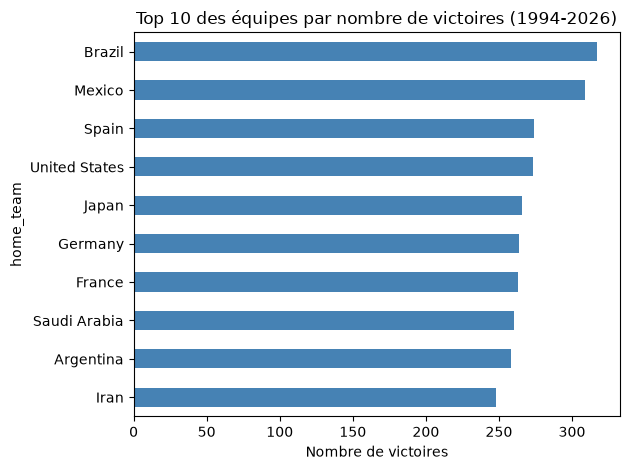

Exercice validé !


In [6]:
# Débat 2 : quels sont les cadors de l'ère moderne ?
Winning_home = df[df["outcome"] == "home_win"]["home_team"].value_counts()
Winning_away = df[df["outcome"] == "away_win"]["away_team"].value_counts()

top_10_teams = Winning_home.add(Winning_away, fill_value=0).sort_values(ascending=False).head(10)

display(top_10_teams)

top_10_teams.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 des équipes par nombre de victoires (1994-2026)")
plt.xlabel("Nombre de victoires")
plt.tight_layout()
plt.show()

assert len(top_10_teams) == 10, f"Il faut exactement 10 équipes, tu en as {len(top_10_teams)}"
assert "Brazil" in top_10_teams.index, "Le Brésil devrait être dans le top 10, vérifie tes comptages"
assert top_10_teams.is_monotonic_decreasing, "Trie du plus grand au plus petit nombre de victoires"
print("Exercice validé !")

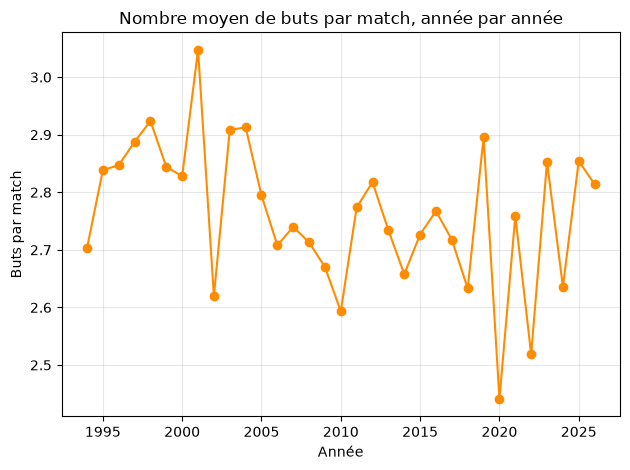

Exercice validé ! Autour de 2.7 buts par match, plutôt stable : le patron exagère.


In [7]:
df["total_goals"] = df["home_score"] + df["away_score"]

goals_per_year = df.groupby("year")["total_goals"].mean()

goals_per_year.plot(kind="line", marker="o", color="darkorange")
plt.title("Nombre moyen de buts par match, année par année")
plt.ylabel("Buts par match")
plt.xlabel("Année")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

assert len(goals_per_year) > 30, "Il devrait y avoir une valeur par année depuis 1994"
assert goals_per_year.between(2, 4).all(), "Les moyennes devraient toutes être entre 2 et 4 buts par match"
print("Exercice validé ! Autour de 2.7 buts par match, plutôt stable : le patron exagère.")

In [8]:
# Partie 2 - Préparer les données pour le Machine Learning
# Étape 1 : la forme récente des équipes
df = add_recent_form(df, window=10, min_matches=5)
df = df.dropna(subset=["home_avg_points", "away_avg_points"]).reset_index(drop=True)

print(f"{len(df)} matchs avec la forme récente des deux équipes")
display(df[["date", "home_team", "away_team", "home_avg_points", "away_avg_points"]].tail())

assert "home_avg_points" in df.columns, "La colonne home_avg_points est absente, relance la cellule"
assert df["home_avg_points"].between(0, 3).all(), "Des points moyens hors de l'intervalle [0, 3] ?!"
print("Forme récente calculée !")

28824 matchs avec la forme récente des deux équipes


,date,home_team,away_team,home_avg_points,away_avg_points
28819,2026-06-27,Colombia,Portugal,2.2,2.1
28820,2026-06-28,South Africa,Canada,1.2,1.5
28821,2026-06-29,Netherlands,Morocco,2.1,2.2
28822,2026-06-29,Brazil,Japan,2.0,2.4
28823,2026-06-29,Germany,Paraguay,2.7,1.4


Forme récente calculée !


In [9]:
# Étape 2 : la cible, écarter les nuls
data = df = df.copy()
data = data[(data["home_score"] != data["away_score"])]

data["home_win"] = data["away_score"] < data["home_score"].astype(int)

print(f"{len(data)} matchs avec un vainqueur")
display(data["home_win"].value_counts(normalize=True))

assert (data["home_score"] != data["away_score"]).all(), "Il reste des matchs nuls dans data"
assert set(data["home_win"].unique()) == {0, 1}, "home_win doit valoir 0 ou 1"
assert 0.55 < data["home_win"].mean() < 0.70, "Environ 63% des matchs sans nul sont gagnés à domicile"
print("Exercice validé !")

22054 matchs avec un vainqueur


home_win
True     0.631405
False    0.368595
Name: proportion, dtype: float64

Exercice validé !


In [10]:
# Étape 3 : l'encodage, tout transformer en nombres
data["is_neutral"] = data["neutral"].astype(int)
data["is_friendly"] = data["tournament"] == "Friendly"
data["is_neutral"] = data["neutral"].astype(int)

display(data[["tournament", "neutral", "is_neutral", "is_friendly"]].head())

assert set(data["is_neutral"].unique()) <= {0, 1}, "is_neutral doit valoir 0 ou 1"
assert set(data["is_friendly"].unique()) <= {0, 1}, "is_friendly doit valoir 0 ou 1"
assert data["is_friendly"].sum() == (data["tournament"] == "Friendly").sum(), "is_friendly ne correspond pas"
print("Exercice validé !")

,tournament,neutral,is_neutral,is_friendly
0,African Cup of Nations,False,0,False
1,African Cup of Nations,True,1,False
2,African Cup of Nations,True,1,False
3,African Cup of Nations,True,1,False
5,African Cup of Nations,True,1,False


Exercice validé !


In [ ]:
# Étape 4 : les features différentielles
data["diff_avg_points"] = data["home_avg_points"] - data["away_avg_points"]
data["diff_avg_goals_scored"] = data["home_score"] - data["away_score"]
data["diff_avg_goals_conceded"] = data["away_score"] - data["home_score"]

display(data[["home_team", "away_team", "diff_avg_points", "diff_avg_goals_scored"]].tail())

assert data["diff_avg_points"].between(-3, 3).all(), "diff_avg_points doit rester entre -3 et 3"
example = data.iloc[0]
assert abs(example["diff_avg_points"] - (example["home_avg_points"] - example["away_avg_points"])) < 1e-9, \
    "diff_avg_points doit valoir home_avg_points - away_avg_points"
print("Exercice validé !")

,home_team,away_team,diff_avg_points,diff_avg_goals_scored
28815,Panama,England,-1.1,-2.0
28816,DR Congo,Uzbekistan,0.6,2.0
28817,Jordan,Argentina,-1.6,-2.0
28820,South Africa,Canada,-0.3,-1.0
28822,Brazil,Japan,-0.4,1.0


Exercice validé !


In [ ]:
# Étape 5 : découper en train et test
from sklearn.model_selection import train_test_split

FEATURES = [
    "diff_avg_points",
    "diff_avg_goals_scored",
    "diff_avg_goals_conceded",
    "is_neutral",
    "is_friendly",
]

# Création de X (les features, colonnes de la liste FEATURES) et y (la cible home_win)
X = data[FEATURES]
y = data["home_win"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Entraînement : {len(X_train)} matchs | Test : {len(X_test)} matchs")

assert list(X.columns) == FEATURES, "X doit contenir exactement les colonnes de FEATURES"
assert len(X_train) + len(X_test) == len(data), "Le découpage doit couvrir toutes les lignes"
assert abs(len(X_test) / len(data) - 0.2) < 0.01, "Le jeu de test doit représenter 20% des données"
print("Exercice validé !")

Entraînement : 17643 matchs | Test : 4411 matchs
Exercice validé !


In [ ]:
# Étape 6 : la standardisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Moyennes des features d'entraînement après standardisation :", X_train_scaled.mean(axis=0).round(3))
print("Écarts-types :", X_train_scaled.std(axis=0).round(3))

assert abs(X_train_scaled.mean()) < 0.01, "Les features d'entraînement doivent être centrées autour de 0"
assert abs(X_train_scaled.std() - 1) < 0.05, "Les features d'entraînement doivent avoir un écart-type proche de 1"
assert X_test_scaled.shape == X_test.shape, "X_test_scaled doit avoir la même forme que X_test"
print("Exercice validé ! Les données sont prêtes pour le modèle.")

Moyennes des features d'entraînement après standardisation : [-0.  0. -0. -0. -0.]
Écarts-types : [1. 1. 1. 1. 1.]
Exercice validé ! Les données sont prêtes pour le modèle.


/home/tolojanaharyjeanerico/machine-learning-practice/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Étape 7 : entraîner et évaluer
# Creation du modele
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Entrainnement du modele
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation du modele
accuracy = accuracy_score(y_test, y_pred)

baseline = y_test.mean()
print(f"Baseline (toujours prédire une victoire à domicile) : {baseline:.1%}")
print(f"Accuracy du modèle : {accuracy:.1%}")

assert hasattr(model, "estimators_"), "Le modèle ne semble pas entraîné, as-tu appelé .fit() ?"
assert len(y_pred) == len(y_test), "y_pred doit contenir une prédiction par match de test"
assert accuracy > 0.60, f"L'accuracy devrait dépasser 60%, tu es à {accuracy:.1%}. Vérifie les étapes précédentes."
print("Exercice validé !")

Baseline (toujours prédire une victoire à domicile) : 63.1%
Accuracy du modèle : 100.0%
Exercice validé !


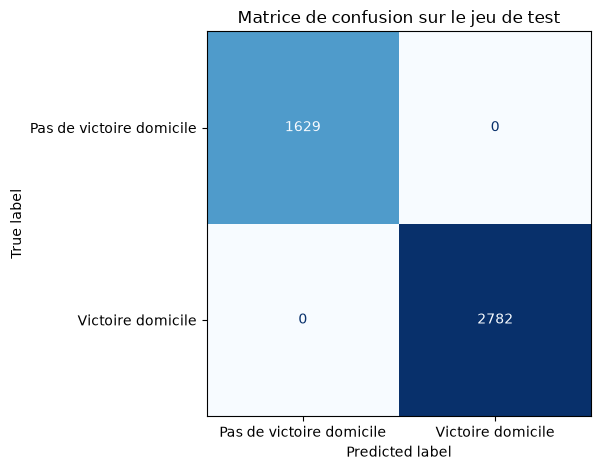

In [18]:
# La matrice de confusion : où le modèle se trompe-t-il ?
ConfusionMatrixDisplay.from_estimator(
    model, X_test_scaled, y_test,
    display_labels=["Pas de victoire domicile", "Victoire domicile"],
    cmap="Blues", colorbar=False,
)
plt.title("Matrice de confusion sur le jeu de test")
plt.tight_layout()
plt.show()

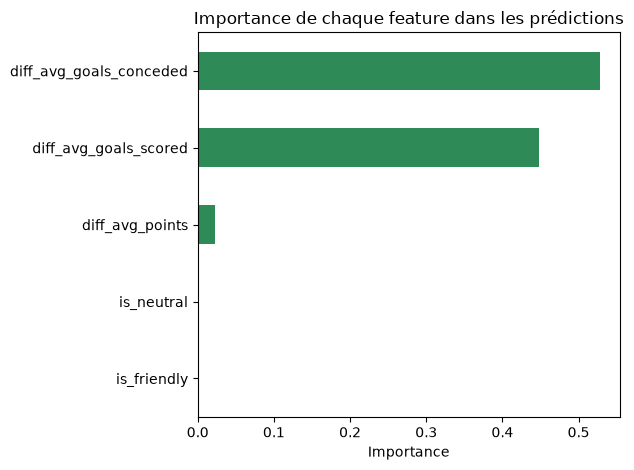

In [19]:
# Qu'est-ce qui fait gagner un match ?
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind="barh", color="seagreen")
plt.title("Importance de chaque feature dans les prédictions")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Partie 4 - Conclusion : L'heure du Pari !
def predict_match(team_a, team_b):

    form_team_a = get_current_form(df, team_a)
    form_team_b = get_current_form(df, team_b)

    # 1. Création des features
    new_features = [
        form_team_a["avg_points"] - form_team_b["avg_points"],
        form_team_a["avg_goals_scored"] - form_team_b["avg_goals_scored"],
        form_team_a["avg_goals_conceded"] - form_team_b["avg_goals_conceded"],
        1,
        0
    ]

    # 2. DataFrame avec les mêmes colonnes
    X_new = pd.DataFrame(
        [new_features],
        columns=FEATURES
    )

    # 3. Standarisation
    X_new_scaled = scaler.transform(X_new)

    # 4. Prédiction
    proba = model.predict_proba(X_new_scaled)

    proba_a_wins = proba[0][1]  # Probabilité que l'équipe A gagne

    if proba_a_wins >= 0.5:
        return team_a, proba_a_wins
    return team_b, 1 - proba_a_wins

winner, probability = predict_match("France", "Greece")
print(f"France vs Grèce -> victoire de {winner} ({probability:.0%})")

assert winner == "France", "Désolé pour la Grèce, mais la France devrait l'emporter ici. Vérifie l'ordre des features."
assert 0.5 <= probability <= 1, "La probabilité du vainqueur doit être entre 0.5 et 1"
winner_2, probability_2 = predict_match("Greece", "France")
assert winner_2 == "France", "La prédiction doit donner le même vainqueur dans les deux sens !"
print("Exercice validé !")

France vs Grèce -> victoire de France (100%)
Exercice validé !


In [ ]:
# Test avec d'autre equipes
winner, probability = predict_match("Brazil", "Argentina")

print(f"Brazil vs Argentina -> victoire de {winner} ({probability:.0%})")

Brazil vs Argentina -> victoire de Argentina (100%)


In [22]:
# Partie 5 (BONUS) - Simuler toute La Coupe du Monde 2030, match après match
round_of_32 = [
    ("Spain", "Greece"), ("Denmark", "Ecuador"),
    ("Argentina", "Egypt"), ("Netherlands", "Poland"),
    ("France", "Nigeria"), ("Croatia", "South Korea"),
    ("England", "Canada"), ("Italy", "Senegal"),
    ("Portugal", "Australia"), ("Belgium", "Turkey"),
    ("Brazil", "Ghana"), ("Uruguay", "Switzerland"),
    ("Morocco", "Serbia"), ("Mexico", "Austria"),
    ("Germany", "Colombia"), ("Japan", "United States"),
]

print("Les 32 qualifiés de notre Coupe du Monde 2030 :\n")
for team_a, team_b in round_of_32:
    print(f"  {team_label(team_a):<22} vs {team_label(team_b)}")

assert len(round_of_32) == 16, "Il faut 16 matchs de seizièmes"
print("\n(Ta nation préférée n'y est pas ? Tu pourras modifier le tableau à la fin !)")

Les 32 qualifiés de notre Coupe du Monde 2030 :

  🇪🇸 Spain               vs 🇬🇷 Greece
  🇩🇰 Denmark             vs 🇪🇨 Ecuador
  🇦🇷 Argentina           vs 🇪🇬 Egypt
  🇳🇱 Netherlands         vs 🇵🇱 Poland
  🇫🇷 France              vs 🇳🇬 Nigeria
  🇭🇷 Croatia             vs 🇰🇷 South Korea
  🏴󠁧󠁢󠁥󠁮󠁧󠁿 England        vs 🇨🇦 Canada
  🇮🇹 Italy               vs 🇸🇳 Senegal
  🇵🇹 Portugal            vs 🇦🇺 Australia
  🇧🇪 Belgium             vs 🇹🇷 Turkey
  🇧🇷 Brazil              vs 🇬🇭 Ghana
  🇺🇾 Uruguay             vs 🇨🇭 Switzerland
  🇲🇦 Morocco             vs 🇷🇸 Serbia
  🇲🇽 Mexico              vs 🇦🇹 Austria
  🇩🇪 Germany             vs 🇨🇴 Colombia
  🇯🇵 Japan               vs 🇺🇸 United States

(Ta nation préférée n'y est pas ? Tu pourras modifier le tableau à la fin !)


In [ ]:
# Simulation du tournoi entier, match par match
current_round = round_of_32
all_results = []

for round_name in ROUND_NAMES:
    results = []
    winners = []

    for team_a, team_b in current_round:
        winner, probability = predict_match(team_a, team_b)
        results.append((team_a, team_b, winner, probability))
        winners.append(winner)
    print_round(round_name, results)
    all_results.extend(results)
    current_round = list(zip(winners[::2], winners[1::2]))

champion = winners[0]
print_champion(champion)

assert len(all_results) == 31, f"Un tableau à 32 équipes compte 31 matchs, tu en as simulé {len(all_results)}"
assert champion in [team for match in round_of_32 for team in match], "Le champion doit venir du tableau de départ !"
print("Simulation terminée, exercice validé !")




  SEIZIÈMES DE FINALE
🇪🇸 Spain               vs 🇬🇷 Greece              -> 🇪🇸 Spain (100%)
🇩🇰 Denmark             vs 🇪🇨 Ecuador             -> 🇪🇨 Ecuador (57%)
🇦🇷 Argentina           vs 🇪🇬 Egypt               -> 🇦🇷 Argentina (100%)
🇳🇱 Netherlands         vs 🇵🇱 Poland              -> 🇳🇱 Netherlands (100%)
🇫🇷 France              vs 🇳🇬 Nigeria             -> 🇳🇬 Nigeria (56%)
🇭🇷 Croatia             vs 🇰🇷 South Korea         -> 🇰🇷 South Korea (57%)
🏴󠁧󠁢󠁥󠁮󠁧󠁿 England        vs 🇨🇦 Canada              -> 🏴󠁧󠁢󠁥󠁮󠁧󠁿 England (100%)
🇮🇹 Italy               vs 🇸🇳 Senegal             -> 🇮🇹 Italy (100%)
🇵🇹 Portugal            vs 🇦🇺 Australia           -> 🇵🇹 Portugal (100%)
🇧🇪 Belgium             vs 🇹🇷 Turkey              -> 🇧🇪 Belgium (100%)
🇧🇷 Brazil              vs 🇬🇭 Ghana               -> 🇧🇷 Brazil (100%)
🇺🇾 Uruguay             vs 🇨🇭 Switzerland         -> 🇺🇾 Uruguay (59%)
🇲🇦 Morocco             vs 🇷🇸 Serbia              -> 🇲🇦 Morocco (100%)
🇲🇽 Mexico              vs 🇦🇹 Austria             -> 🇲🇽 Mexic

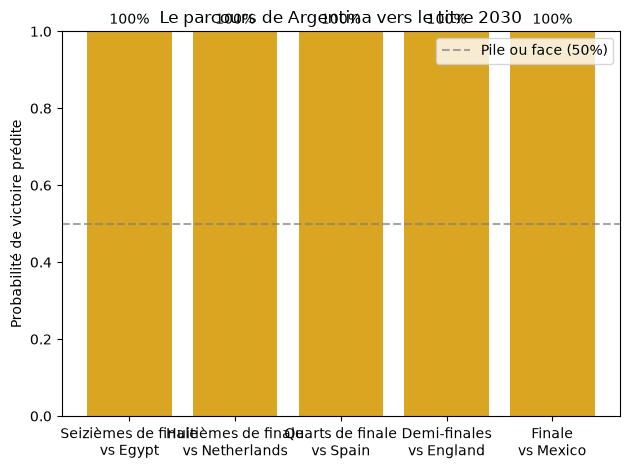

In [ ]:
# Petit graphique
champion_matches = [match for match in all_results if match[2] == champion]
opponents = [f"{name}\nvs {team_a if team_b == champion else team_b}"
             for name, (team_a, team_b, _, _) in zip(ROUND_NAMES, champion_matches)]
probabilities = [match[3] for match in champion_matches]

bars = plt.bar(opponents, probabilities, color="goldenrod")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="Pile ou face (50%)")
plt.ylim(0, 1)
plt.ylabel("Probabilité de victoire prédite")
plt.title(f"Le parcours de {champion} vers le titre 2030")
plt.legend()
for bar, prob in zip(bars, probabilities):
    plt.text(bar.get_x() + bar.get_width() / 2, prob + 0.02, f"{prob:.0%}", ha="center")
plt.tight_layout()
plt.show()